# Analysis of Daily Activity Dataset

### Overview
Detailed analysis of daily activity data, including trend visualizations, descriptive statistics, and correlation analysis, along with inferences and future recommendations.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
import numpy as np

# Load the dataset
file_path = 'Daily_Activity_metrics copy.csv'
data = pd.read_csv(file_path)

# Convert 'Date' column to datetime format for consistency in time-based analysis
# data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')


## Data Overview

In [3]:
data.head()

,Date,Move Minutes count,Calories (kcal),Distance (m),Average heart rate (bpm),Max heart rate (bpm),Min heart rate (bpm),Average speed (m/s),Max speed (m/s),Min speed (m/s),Step count,Walking duration (ms),Cumulative Steps(Thousand),Cumulative Distance (Km),Distance (Km),Calories (1000kcal),Step count(1000)
0,2024-08-30,88,2180.902432,3270.350968,93.454545,122,66,0.522351,1.293584,0.261528,7715.0,758619.0,7.715,3.270351,3.270351,2.180902,7.715
1,2024-08-31,142,2661.979075,5800.165280,93.951220,124,63,0.480490,1.454929,0.261528,8035.0,1652517.0,15.750,9.070516,5.800165,2.661979,8.035
2,2024-09-03,197,3493.596952,7727.318938,86.155963,108,64,0.534038,1.411924,0.250158,11467.0,4731928.0,27.217,16.797835,7.727319,3.493597,11.467
3,2024-09-04,147,3141.232623,5859.941994,85.685185,108,69,0.608777,1.419730,0.252373,10786.0,4401899.0,38.003,22.657777,5.859942,3.141233,10.786
4,2024-09-05,101,2273.139307,3272.876948,88.304878,110,72,0.573502,1.680236,0.250158,7442.0,2162620.0,45.445,25.930654,3.272877,2.273139,7.442


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        71 non-null     object 
 1   Move Minutes count          71 non-null     int64  
 2   Calories (kcal)             71 non-null     float64
 3   Distance (m)                71 non-null     float64
 4   Average heart rate (bpm)    71 non-null     float64
 5   Max heart rate (bpm)        71 non-null     int64  
 6   Min heart rate (bpm)        71 non-null     int64  
 7   Average speed (m/s)         71 non-null     float64
 8   Max speed (m/s)             71 non-null     float64
 9   Min speed (m/s)             71 non-null     float64
 10  Step count                  71 non-null     float64
 11  Walking duration (ms)       71 non-null     float64
 12  Cumulative Steps(Thousand)  71 non-null     float64
 13  Cumulative Distance (Km)    71 non-nu

# Data Cleaning
#### Days When I didn't wore watch!
- Identify
- Replace with nan

In [5]:
threshold=1000
steps_below_threshold = data[data['Step count'] < threshold].shape[0]
print(f"Number of steps below {threshold}: {steps_below_threshold}")

Number of steps below 1000: 0


In [6]:
data.loc[data['Step count'] < threshold, 'Step count'] = np.nan

- Identify Missing values

In [7]:
data.isna().sum()

Date                          0
Move Minutes count            0
Calories (kcal)               0
Distance (m)                  0
Average heart rate (bpm)      0
Max heart rate (bpm)          0
Min heart rate (bpm)          0
Average speed (m/s)           0
Max speed (m/s)               0
Min speed (m/s)               0
Step count                    0
Walking duration (ms)         0
Cumulative Steps(Thousand)    0
Cumulative Distance (Km)      0
Distance (Km)                 0
Calories (1000kcal)           0
Step count(1000)              0
dtype: int64

- Imputing Missing values

In [8]:
# Ensure 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'], infer_datetime_format=True)

# Drop rows where 'Date' is missing
data = data.dropna(subset=['Date'])

# Calculate the mean for each field by day of the week
mean_values_by_day = data.groupby(data['Date'].dt.day_name()).mean()

# Function to replace missing values with the mean of the corresponding day of the week
def replace_with_mean(row):
    for column in data.columns:
        if pd.isna(row[column]):
            row[column] = mean_values_by_day.loc[row['Date'].day_name(), column]
    return row

# Apply the function to the dataframe
df = data.apply(replace_with_mean, axis=1)


## Descriptive Statistics

In [9]:
df.describe()

,Date,Move Minutes count,Calories (kcal),Distance (m),Average heart rate (bpm),Max heart rate (bpm),Min heart rate (bpm),Average speed (m/s),Max speed (m/s),Min speed (m/s),Step count,Walking duration (ms),Cumulative Steps(Thousand),Cumulative Distance (Km),Distance (Km),Calories (1000kcal),Step count(1000)
count,71,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,7.100000e+01,71.000000,71.000000,71.000000,71.000000,71.000000
mean,2024-10-08 00:00:00,78.577465,2027.504873,3487.509537,92.850747,116.619718,67.985915,0.563459,1.588369,0.267437,5888.792272,1.459481e+06,210.055978,132.042863,3.487510,2.027505,5.888792
min,2024-08-30 00:00:00,3.000000,1007.932077,199.065418,80.153409,97.000000,56.000000,0.343126,1.035735,0.243344,1016.000000,-1.146354e+04,7.715000,3.270351,0.199065,1.007932,1.016000
25%,2024-09-18 12:00:00,26.500000,1351.903350,983.949736,88.375413,112.500000,64.000000,0.501473,1.415827,0.250158,4381.000000,3.236105e+05,135.069500,85.189737,0.983950,1.351903,4.381000
50%,2024-10-08 00:00:00,74.000000,1989.096046,3884.964778,93.970588,117.000000,68.000000,0.568613,1.524724,0.251878,5480.000000,1.001838e+06,218.362198,131.946837,3.884965,1.989096,5.480000
75%,2024-10-27 12:00:00,119.000000,2600.326710,5180.423478,96.786399,121.000000,71.000000,0.641985,1.684642,0.272899,8082.500000,2.200728e+06,294.636591,184.794739,5.180423,2.600327,8.082500
max,2024-11-15 00:00:00,200.000000,3927.917785,10130.592509,102.951389,144.000000,91.000000,0.753153,2.872956,0.341124,12380.000000,5.505097e+06,372.879234,247.613177,10.130593,3.927918,12.380000
std,NaN,54.372173,715.426608,2369.482275,5.411183,7.687404,5.991644,0.100354,0.350516,0.027079,2859.597355,1.460675e+06,102.127138,67.356772,2.369482,0.715427,2.859597


## Plot: Daily Step Count Over Time

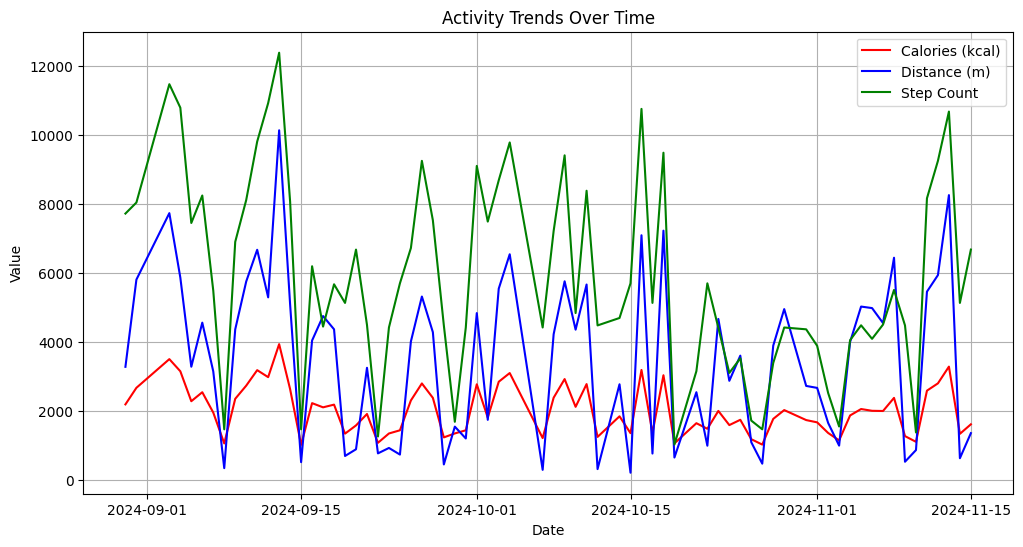

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Calories (kcal)'], label='Calories (kcal)', color='r')
plt.plot(df['Date'], df['Distance (m)'], label='Distance (m)', color='b')
plt.plot(df['Date'], df['Step count'], label='Step Count', color='g')
plt.title('Activity Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


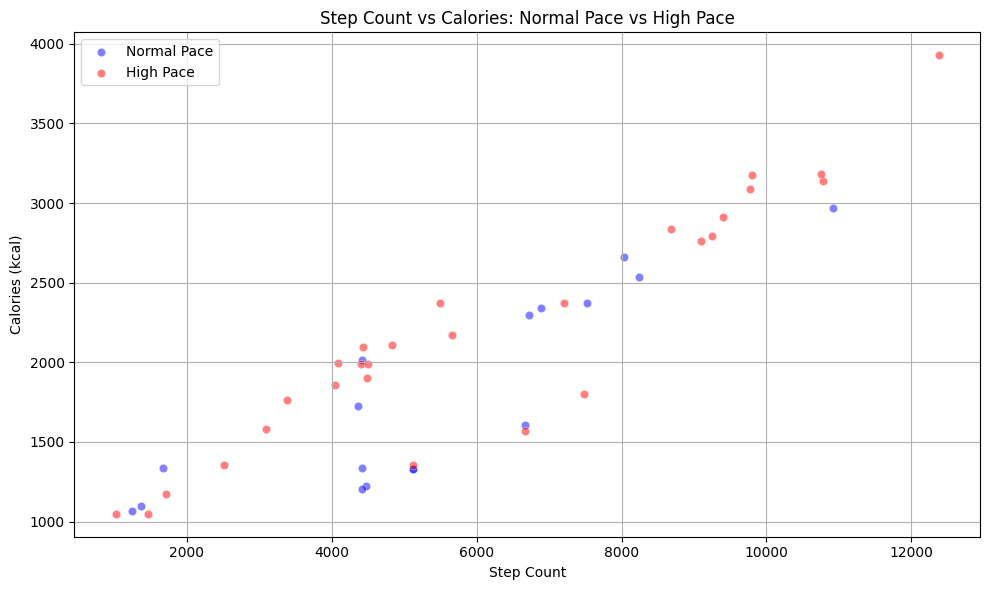

In [11]:
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x='Step count', y='Calories (kcal)', data=df,color='blue', alpha=0.5)
# plt.xlabel('Step Count')
# plt.ylabel('Calories (kcal)')
# plt.title('Step Count vs Calories')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# Define thresholds for normal and high pace
normal_pace_threshold =0.5  # m/s
high_pace_threshold =0.6   # m/s

# Filter data for normal and high pace
normal_pace_data = df[df['Average speed (m/s)'] < normal_pace_threshold]
high_pace_data = df[df['Average speed (m/s)'] >= high_pace_threshold]

# Plot normal pace data
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Step count', y='Calories (kcal)', data=normal_pace_data, color='blue', alpha=0.5, label='Normal Pace')
sns.scatterplot(x='Step count', y='Calories (kcal)', data=high_pace_data, color='red', alpha=0.5, label='High Pace')
plt.xlabel('Step Count')
plt.ylabel('Calories (kcal)')
plt.title('Step Count vs Calories: Normal Pace vs High Pace')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

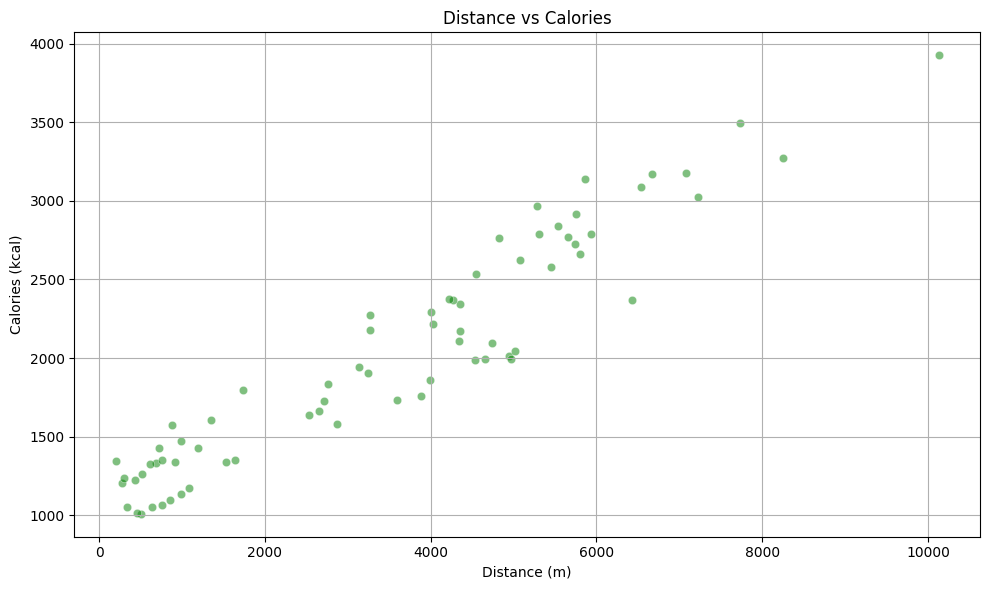

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Distance (m)', y='Calories (kcal)', data=df,color='green', alpha=0.5)
plt.xlabel('Distance (m)')
plt.ylabel('Calories (kcal)')
plt.title('Distance vs Calories')
plt.grid(True)
plt.tight_layout()
plt.show()

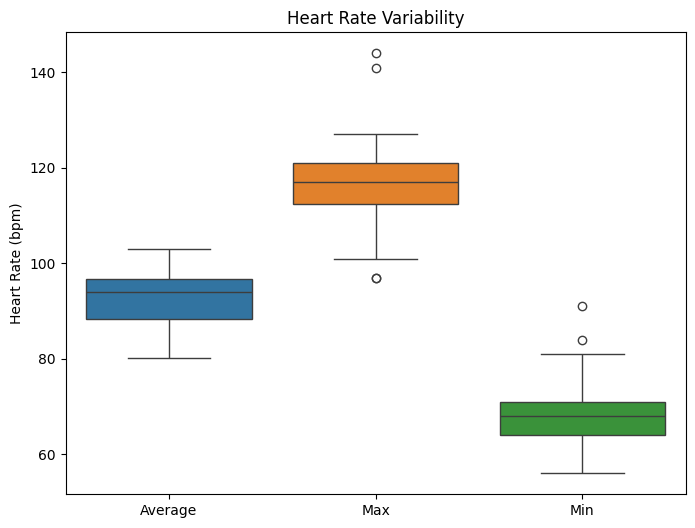

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[['Average heart rate (bpm)', 'Max heart rate (bpm)', 'Min heart rate (bpm)']])
plt.title('Heart Rate Variability')
plt.ylabel('Heart Rate (bpm)')
plt.xticks([0, 1, 2], ['Average', 'Max', 'Min'])
plt.show()


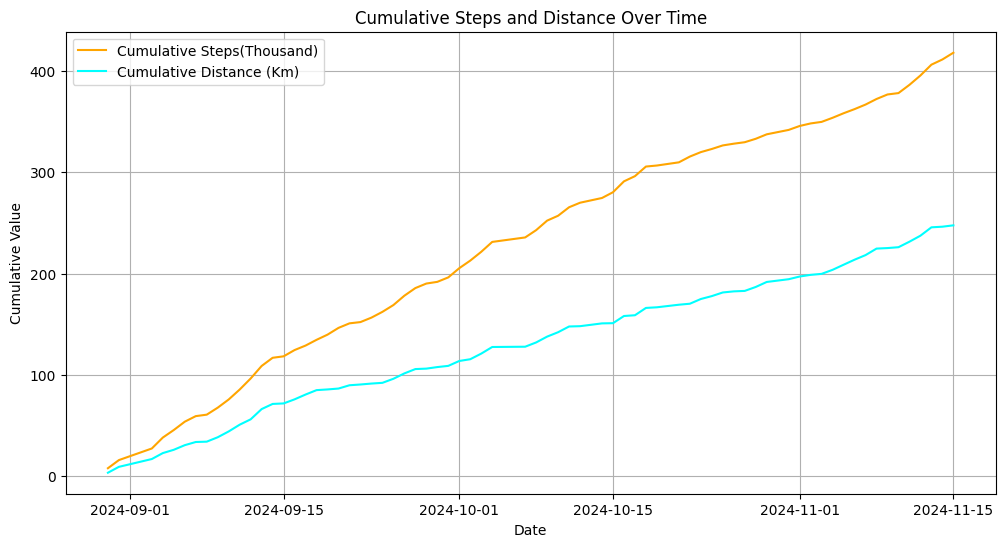

In [14]:
df['Cumulative Steps(Thousand)'] = (df['Step count']/1000).cumsum()
df['Cumulative Distance (Km)'] = (df['Distance (m)']/1000).cumsum()

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Cumulative Steps(Thousand)'], label='Cumulative Steps(Thousand)', color='orange')
plt.plot(df['Date'], df['Cumulative Distance (Km)'], label='Cumulative Distance (Km)', color='cyan')
plt.title('Cumulative Steps and Distance Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Value')
plt.legend()
plt.grid(True)
plt.show()


In [15]:
# # Add a 'Weekday' column
# df['Weekday'] = df['Date'].dt.day_name()
# df['Type'] = df['Weekday'].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')

# # Group data
# grouped = df.groupby('Type')[['Step count', 'Calories (kcal)', 'Distance (m)']].mean()

# # Plot
# grouped[['Step count']].plot(kind='bar', color='purple', legend=False)
# plt.title('Average Step Count: Weekdays vs. Weekends')
# plt.ylabel('Steps')
# plt.xticks(rotation=0)
# plt.show()


In [16]:
average_steps_per_day = df.groupby(data['Date'].dt.day_name())['Step count'].mean()
print(average_steps_per_day.sort_values())

Date
Sunday       1457.750000
Saturday     4471.142857
Monday       4973.266667
Thursday     6221.429752
Tuesday      6866.049587
Friday       7477.361111
Wednesday    7976.530000
Name: Step count, dtype: float64


In [17]:
holiday_threshold=3000
# Filter the dataframe for step counts below holiday threshold
days_below_3000 = df[df['Step count'] < holiday_threshold]

# Extract the day of the week for these days
days_below_3000['Day of Week'] = days_below_3000['Date'].dt.day_name()

# Get the frequency of each day of the week
day_frequency = days_below_3000['Day of Week'].value_counts()
print("------------Days Counts below 3000 steps------------")
print(day_frequency)

------------Days Counts below 3000 steps------------
Day of Week
Sunday      7
Saturday    3
Name: count, dtype: int64


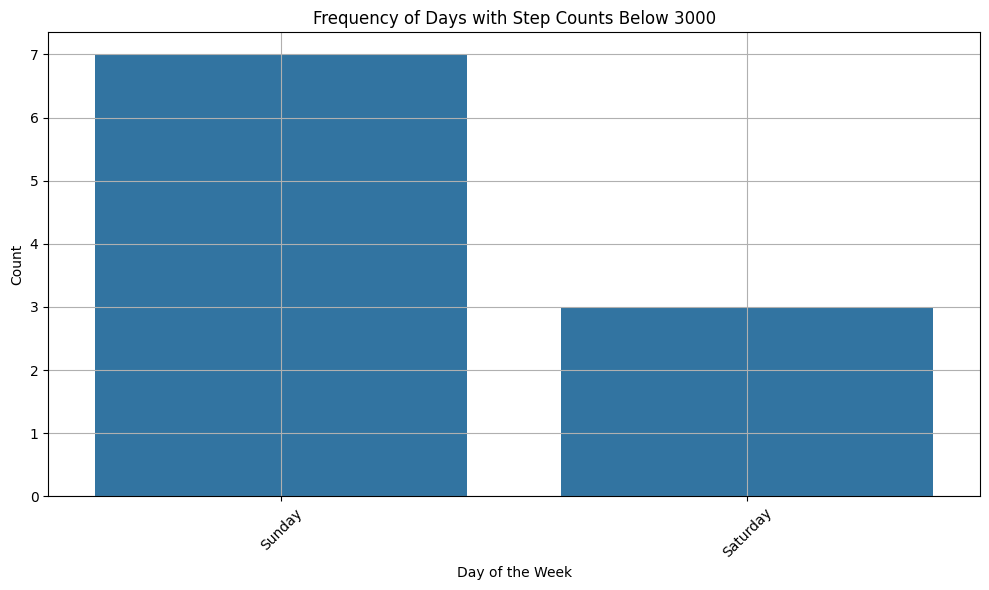

In [18]:
# Convert the Series to a DataFrame and reset the index
day_frequency_df = day_frequency.reset_index()
day_frequency_df.columns = ['Day of the Week', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Day of the Week', y='Count', data=day_frequency_df)
plt.xlabel('Day of the Week')
plt.ylabel('Count')
plt.title('Frequency of Days with Step Counts Below 3000')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Correlation Analysis

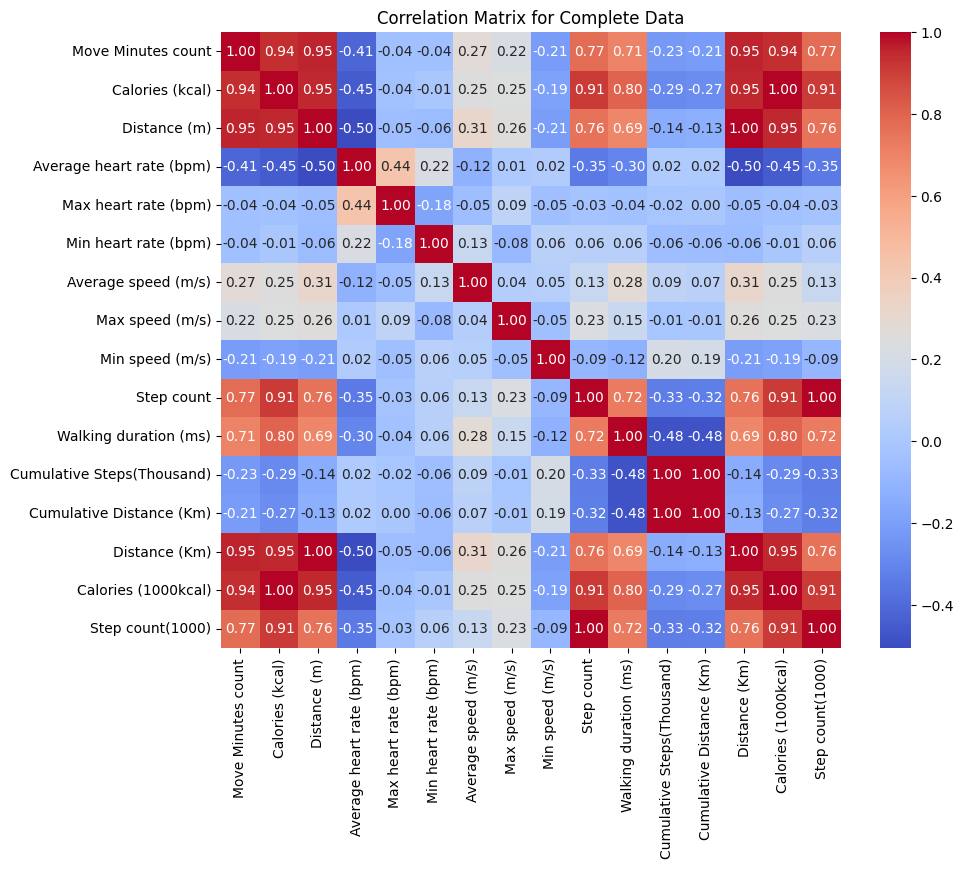

In [19]:
corr_data=df.drop(['Date'], axis=1)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix for Complete Data")
plt.show()
    


# Summary of Analysis

### Intuition, Objectives, and Challenges

**Intuition**: The dataset captures daily metrics related to physical activity, useful for tracking health and fitness patterns.

**Objectives**: Monitor activity levels, identify high-activity days, and assess calorie burn.

**Challenges**: Handling missing data, ensuring data consistency, and interpreting correlations carefully.

### Inferences
- Higher step counts and speeds correlate with higher calorie burn.
- Heart rate data shows varying cardiovascular effort, helpful for fitness planning.
- Activity levels fluctuate, with some days showing peak activity.

### Future Scope
1. **Time-Series Analysis** for trends and goal-setting.
2. **Predictive Modeling** for calorie and activity forecasting.
3. **Activity Classification** to label sedentary vs. active days.
4. **Personalized Recommendations** for fitness or dietary guidance.
    